<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L4_Self_Attention_and_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=NVkqsV8J4mc) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P04.pdf)

In [1]:
# Week 8, Lecture 4: Self-Attention and Transformers
from IPython.display import HTML, display

VIDEO_ID = "NVkqsV8J4mc"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 4: Self-Attention and Transformers

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.4 Self-Attention and Transformers**.

**What you will learn**

- Why sequential computation is the bottleneck that motivated dropping the RNN entirely.
- **Query, key and value**, and the scaled dot-product attention $\mathrm{softmax}(QK^\top/\sqrt{d_k})V$.
- Why the $\sqrt{d_k}$ scaling is there — the reason the slides assert but do not give.
- **Multi-head attention**: eight heads, $d_k = d_{model}/h$, concatenate, project by $W^O$.
- **Positional encoding**, and a check that settles a contradiction in the slides.
- The encoder and decoder blocks, and what the causal mask actually does.

**Contents**

1. Why drop the RNN
2. Query, key, value
3. Scaled dot-product attention
4. Multi-head attention
5. Positional encoding
6. The encoder and decoder blocks
7. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

Lecture 1 of this week introduced attention as a way past the encoder-decoder bottleneck,
and listed scaled dot-product attention among the score functions. Lectures 2 and 3 used
attention on top of a recurrent decoder. This lecture removes the recurrence altogether.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Why drop the RNN

Two problems, one cause. **Sequential computation prevents parallelisation**: step $t$ cannot
start until step $t-1$ has finished. And even with LSTMs and GRUs, the **path length between
co-dependent states grows with the sequence length**, so long-range dependencies still have
far to travel.

The slides put the conclusion as a question: *"if attention gives us access to any state,
maybe we don't need the RNN?"*

In [3]:
# Path length between two positions: linear for an RNN, constant for self-attention.
print(f'  {"sequence length":>16s} {"RNN path":>10s} {"self-attention path":>21s}')
for T in (10, 50, 100, 500):
    print(f'  {T:16d} {T - 1:10d} {1:21d}')

print('\n  in an RNN, information from position 0 must pass through T-1 intermediate states')
print('  to reach position T-1; self-attention connects any two positions in a single step')

# And the sequential dependency: an RNN cannot compute step t before step t-1.
T_demo, d_demo = 8, 16
X = torch.randn(T_demo, d_demo)
Wq = torch.randn(d_demo, d_demo)
all_at_once = X @ Wq                          # every position, one matrix multiply
one_at_a_time = torch.stack([X[t] @ Wq for t in range(T_demo)])
assert torch.allclose(all_at_once, one_at_a_time, atol=1e-5)
print(f'\n  self-attention projections are one matmul over all {T_demo} positions at once;')
print('  there is no ordering constraint to respect')

   sequence length   RNN path   self-attention path
                10          9                     1
                50         49                     1
               100         99                     1
               500        499                     1

  in an RNN, information from position 0 must pass through T-1 intermediate states
  to reach position T-1; self-attention connects any two positions in a single step

  self-attention projections are one matmul over all 8 positions at once;
  there is no ordering constraint to respect


## 2. Query, key, value

From each input vector $x_i$ the model creates three vectors by multiplying with learned
matrices:

$$Q = XW^Q, \qquad K = XW^K, \qquad V = XW^V$$

The slides give the paper's dimensions: $x \in \mathbb{R}^{512}$ and $q, k, v \in \mathbb{R}^{64}$.
They then ask what the shapes of $W^Q, W^K, W^V$ must be, and leave it unanswered — so let us
answer it.

They also ask whether $q, k, v$ must be smaller than $x$. The answer given is no; the reason
is that with $h$ heads of width $d_{model}/h$, the total cost of multi-head attention matches
single-head attention at full width.

In [4]:
# The projection shapes the slides ask about, and the identity they never write.
d_model, d_k, h = 512, 64, 8
n_tokens = 4

X = torch.randn(n_tokens, d_model)
WQ = torch.randn(d_model, d_k)
WK = torch.randn(d_model, d_k)
WV = torch.randn(d_model, d_k)

Q, K, V = X @ WQ, X @ WK, X @ WV

assert WQ.shape == (d_model, d_k) == (512, 64), 'the projection is d_model x d_k'
assert Q.shape == K.shape == V.shape == (n_tokens, d_k)
assert d_k == d_model // h, 'd_k should be d_model / h'

print(f'  x is {d_model}-d and q, k, v are {d_k}-d, so W^Q, W^K, W^V are {tuple(WQ.shape)}')
print(f'  the deck never states it, but d_k = d_model / h = {d_model} / {h} = {d_model // h}')
print(f'\n  X {tuple(X.shape)} -> Q, K, V each {tuple(Q.shape)}')

  x is 512-d and q, k, v are 64-d, so W^Q, W^K, W^V are (512, 64)
  the deck never states it, but d_k = d_model / h = 512 / 8 = 64

  X (4, 512) -> Q, K, V each (4, 64)


## 3. Scaled dot-product attention

Score every position against every other by the dot product of a query with a key, divide by
$\sqrt{d_k}$, softmax, and use the result to weight the values:

$$Z = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

With $d_k = 64$ the divisor is $\sqrt{64} = 8$ — the "divide by 8" in the slides' figure.
The worked example there scores 112 and 96, giving 14 and 12 after scaling, and a softmax of
0.88 and 0.12.

In [5]:
# Reproduce the slides' worked numbers exactly.
raw_scores = torch.tensor([112.0, 96.0])
scaled = raw_scores / np.sqrt(d_k)
weights = torch.softmax(scaled, dim=0)

assert np.sqrt(d_k) == 8.0
assert torch.allclose(scaled, torch.tensor([14.0, 12.0]))
assert torch.allclose(weights, torch.tensor([0.8808, 0.1192]), atol=1e-4)

print(f'  raw scores      {raw_scores.tolist()}')
print(f'  / sqrt(d_k) = 8 {scaled.tolist()}')
print(f'  softmax         {[round(v, 4) for v in weights.tolist()]}  (the slides print 0.88 and 0.12)')
print(f'  sums to {weights.sum():.6f}')

  raw scores      [112.0, 96.0]
  / sqrt(d_k) = 8 [14.0, 12.0]
  softmax         [0.8808, 0.1192]  (the slides print 0.88 and 0.12)
  sums to 1.000000


In [6]:
# Why the scaling? The slides say "more stable gradients" but not why. Here is why.
print(f'  {"d_k":>6s} {"std of q.k":>12s} {"max softmax":>13s} {"gradient norm":>15s}')
for dk in (8, 32, 128, 512, 2048):
    g = torch.Generator().manual_seed(0)
    q = torch.randn(2000, dk, generator=g)
    k = torch.randn(2000, dk, generator=g)
    dots = (q * k).sum(1)                       # dot products of unit-variance vectors
    logits = torch.randn(1, dk, generator=g) @ torch.randn(dk, 8, generator=g)
    logits = logits.squeeze(0) * np.sqrt(dk) / np.sqrt(dk)   # representative magnitude
    unscaled = dots[:8]
    w = torch.softmax(unscaled, dim=0)
    x_ = unscaled.clone().requires_grad_(True)
    torch.softmax(x_, dim=0).max().backward()
    print(f'  {dk:6d} {dots.std():12.2f} {w.max():13.4f} {x_.grad.norm():15.2e}')

print(f'\n  the variance of a dot product grows with d_k (std ~ sqrt(d_k)), so unscaled logits')
print('  spread out, the softmax saturates towards one-hot, and its gradient collapses.')
print(f'  dividing by sqrt(d_k) holds the spread constant, whatever d_k is.')

     d_k   std of q.k   max softmax   gradient norm
       8         2.82        0.6899        2.74e-01
      32         5.71        0.9791        2.34e-02
     128        11.28        0.5686        2.96e-01
     512        22.71        1.0000        2.52e-06
    2048        46.00        1.0000        2.76e-19

  the variance of a dot product grows with d_k (std ~ sqrt(d_k)), so unscaled logits
  spread out, the softmax saturates towards one-hot, and its gradient collapses.
  dividing by sqrt(d_k) holds the spread constant, whatever d_k is.


In [7]:
# Full scaled dot-product attention, with the properties it must satisfy.
def attention(Q, K, V, mask=None):
    scores = Q @ K.T / np.sqrt(Q.shape[-1])
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    A = torch.softmax(scores, dim=-1)
    return A @ V, A

Z, A = attention(Q, K, V)
assert A.shape == (n_tokens, n_tokens), 'the attention matrix is tokens x tokens'
assert torch.allclose(A.sum(-1), torch.ones(n_tokens), atol=1e-5), 'every row must sum to 1'
assert Z.shape == (n_tokens, d_k)

print(f'  Q {tuple(Q.shape)} @ K^T {tuple(K.T.shape)} -> scores {tuple(A.shape)}')
print(f'  softmax rows sum to 1: {A.sum(-1).tolist()}')
print(f'  output Z {tuple(Z.shape)}, same width as V')

  Q (4, 64) @ K^T (64, 4) -> scores (4, 4)
  softmax rows sum to 1: [1.0, 1.0, 1.0, 1.0]
  output Z (4, 64), same width as V


## 4. Multi-head attention

One attention layer is dominated by the token itself. Multi-head attention runs $h = 8$ of
them in parallel, each with its own $W^Q_i, W^K_i, W^V_i$ projecting into a different
**representation subspace**, then concatenates the results and projects once more:

$$Z = \mathrm{Concat}(Z_0, \dots, Z_7)\,W^O$$

Because each head is $d_k = d_{model}/h$ wide, the concatenation returns to $d_{model}$ — so
multi-head attention is **shape-preserving**.

In [8]:
# Multi-head attention from scratch, and its parameter count.
class MultiHead(nn.Module):
    def __init__(self, d_model=512, h=8):
        super().__init__()
        self.h, self.d_k = h, d_model // h
        self.WQ = nn.Linear(d_model, d_model, bias=False)
        self.WK = nn.Linear(d_model, d_model, bias=False)
        self.WV = nn.Linear(d_model, d_model, bias=False)
        self.WO = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X, mask=None):
        T_, d = X.shape
        q = self.WQ(X).view(T_, self.h, self.d_k).transpose(0, 1)   # (h, T, d_k)
        k = self.WK(X).view(T_, self.h, self.d_k).transpose(0, 1)
        v = self.WV(X).view(T_, self.h, self.d_k).transpose(0, 1)
        scores = q @ k.transpose(1, 2) / np.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))
        A = torch.softmax(scores, dim=-1)
        Z = (A @ v).transpose(0, 1).reshape(T_, d)                  # concat the heads
        return self.WO(Z), A

mha = MultiHead()
X_seq = torch.randn(10, d_model)
out, A_heads = mha(X_seq)

assert out.shape == X_seq.shape, 'multi-head attention must be shape-preserving'
assert A_heads.shape == (h, 10, 10), 'one attention matrix per head'
assert torch.allclose(A_heads.sum(-1), torch.ones(h, 10), atol=1e-5)

n_params = sum(p.numel() for p in mha.parameters())
expected = 4 * d_model * d_model
assert n_params == expected == 1_048_576 == 2 ** 20

print(f'  input {tuple(X_seq.shape)} -> output {tuple(out.shape)}   (shape-preserving)')
print(f'  {h} heads, each {mha.d_k}-d; concatenated {h} x {mha.d_k} = {h * mha.d_k} = d_model')
print(f'  parameters: 4 x {d_model} x {d_model} = {n_params:,} = 2^{int(np.log2(n_params))}')

  input (10, 512) -> output (10, 512)   (shape-preserving)
  8 heads, each 64-d; concatenated 8 x 64 = 512 = d_model
  parameters: 4 x 512 x 512 = 1,048,576 = 2^20


## 5. Positional encoding

Self-attention has no notion of order: permute the inputs and the outputs permute with them.
Since order matters for language, position has to be injected explicitly:

$$PE_{pos,2i} = \sin\!\left(\frac{pos}{10000^{2i/d_{emb}}}\right), \qquad
PE_{pos,2i+1} = \cos\!\left(\frac{pos}{10000^{2i/d_{emb}}}\right)$$

**A contradiction in the slides worth resolving.** One bullet says the final input embeddings
are the **concatenation** of the learnable embedding and the positional encoding. But the
architecture figure on a later slide shows a $\oplus$ sum, and the encoder slide insists every
sublayer outputs $d_{model} = 512$. Concatenation would make the input 1024 wide. The two
cannot both be right, and the check below settles it.

In [9]:
# First, the permutation-equivariance that makes positional encoding necessary.
X_small = torch.randn(5, d_model)
perm = torch.randperm(5)
out_a, _ = mha(X_small)
out_b, _ = mha(X_small[perm])
assert torch.allclose(out_a[perm], out_b, atol=1e-4), 'attention should be permutation-equivariant'
print('  permuting the inputs permutes the outputs identically:')
print('  self-attention alone cannot tell position 0 from position 4')

  permuting the inputs permutes the outputs identically:
  self-attention alone cannot tell position 0 from position 4


In [10]:
# The sinusoidal encoding, and the property at pos = 0.
def positional_encoding(max_len, d_emb):
    pos = torch.arange(max_len).float()[:, None]
    i = torch.arange(0, d_emb, 2).float()
    denom = torch.pow(10000, i / d_emb)
    pe = torch.zeros(max_len, d_emb)
    pe[:, 0::2] = torch.sin(pos / denom)
    pe[:, 1::2] = torch.cos(pos / denom)
    return pe

PE = positional_encoding(100, d_model)
assert PE.shape == (100, d_model)
assert torch.allclose(PE[0, 0::2], torch.zeros(d_model // 2), atol=1e-6), 'sin(0) should be 0'
assert torch.allclose(PE[0, 1::2], torch.ones(d_model // 2), atol=1e-6), 'cos(0) should be 1'
print(f'  PE {tuple(PE.shape)};  at pos=0 every sine term is 0 and every cosine term is 1')

# Now settle the slides' contradiction.
emb = torch.randn(100, d_model)
added = emb + PE
concatenated = torch.cat([emb, PE], dim=1)

assert added.shape == (100, d_model), 'addition preserves d_model'
assert concatenated.shape == (100, 2 * d_model), 'concatenation doubles it'

print(f'\n  addition      -> {tuple(added.shape)}   d_model preserved')
print(f'  concatenation -> {tuple(concatenated.shape)}   d_model doubled')
print(f'\n  The encoder requires every sublayer to output {d_model}, and the residual')
print('  connection LayerNorm(x + SubLayer(x)) needs both terms the same width.')
print('  Concatenation breaks both, so the slide bullet is wrong: they are ADDED.')

  PE (100, 512);  at pos=0 every sine term is 0 and every cosine term is 1

  addition      -> (100, 512)   d_model preserved
  concatenation -> (100, 1024)   d_model doubled

  The encoder requires every sublayer to output 512, and the residual
  connection LayerNorm(x + SubLayer(x)) needs both terms the same width.
  Concatenation breaks both, so the slide bullet is wrong: they are ADDED.


## 6. The encoder and decoder blocks

The **encoder** is a stack of $N = 6$ identical layers. Each has a multi-head self-attention
sublayer and a position-wise feedforward network, and each sublayer is wrapped as

$$\mathrm{LayerNorm}\big(x + \mathrm{SubLayer}(x)\big)$$

so every sublayer outputs $d_{model} = 512$.

The **decoder** is also $N = 6$ layers, but each has *two* attention sublayers. The first is
**masked**, so a position cannot attend to positions after it — you must not look into the
future of the target sequence when predicting the current position.

In [11]:
# One encoder layer, and what the causal mask does in the decoder.
class EncoderLayer(nn.Module):
    def __init__(self, d_model=512, h=8, d_ff=2048):
        super().__init__()
        self.attn = MultiHead(d_model, h)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.n1, self.n2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        a, _ = self.attn(x, mask)
        x = self.n1(x + a)                       # LayerNorm(x + SubLayer(x))
        return self.n2(x + self.ff(x))

layer = EncoderLayer()
x_in = torch.randn(12, d_model)
assert layer(x_in).shape == x_in.shape, 'the encoder layer must preserve d_model'
print(f'  encoder layer: {tuple(x_in.shape)} -> {tuple(layer(x_in).shape)}   (residual needs this)')
print(f'  a stack of N=6 such layers, all at d_model={d_model}')

  encoder layer: (12, 512) -> (12, 512)   (residual needs this)
  a stack of N=6 such layers, all at d_model=512


In [12]:
# The causal mask: rows still sum to 1, and the future genuinely cannot leak backwards.
T_m = 6
causal = torch.triu(torch.ones(T_m, T_m, dtype=torch.bool), diagonal=1)

X_m = torch.randn(T_m, d_model)
out_masked, A_m = mha(X_m, mask=causal)

assert torch.allclose(A_m.sum(-1), torch.ones(h, T_m), atol=1e-5), 'masked rows must still sum to 1'
assert (A_m[:, 0, 1:] == 0).all(), 'position 0 must not see anything after it'

# Change only the LAST token and confirm earlier outputs are untouched.
X_alt = X_m.clone()
X_alt[-1] = torch.randn(d_model)
out_alt, _ = mha(X_alt, mask=causal)
assert torch.allclose(out_masked[:-1], out_alt[:-1], atol=1e-5), 'the future leaked backwards'

print(f'  attention matrix per head {tuple(A_m.shape[1:])}, still row-stochastic after masking')
print(f'  row 0 attends to {int((A_m[0, 0] > 0).sum())} of {T_m} positions (itself only)')
print(f'  row {T_m-1} attends to {int((A_m[0, -1] > 0).sum())} of {T_m} positions (all of them)')
print('\n  changing the last token left every earlier output unchanged: no leakage')

  attention matrix per head (6, 6), still row-stochastic after masking
  row 0 attends to 1 of 6 positions (itself only)
  row 5 attends to 6 of 6 positions (all of them)

  changing the last token left every earlier output unchanged: no leakage


## 7. Explore and verify

The final check is against PyTorch's own implementation — if our from-scratch multi-head
attention is right, `nn.MultiheadAttention` should agree once the weights are mapped.

In [13]:
# Our multi-head attention == nn.MultiheadAttention, once the weights are mapped across.
# PyTorch packs W^Q, W^K, W^V into a single in_proj_weight of shape (3*d_model, d_model).
torch.manual_seed(0)
ours = MultiHead(d_model=64, h=4)
ref = nn.MultiheadAttention(embed_dim=64, num_heads=4, bias=False, batch_first=True)

with torch.no_grad():
    ref.in_proj_weight.copy_(torch.cat([ours.WQ.weight, ours.WK.weight, ours.WV.weight]))
    ref.out_proj.weight.copy_(ours.WO.weight)

x_t = torch.randn(7, 64)
our_out, _ = ours(x_t)
ref_out, _ = ref(x_t[None], x_t[None], x_t[None])

assert torch.allclose(our_out, ref_out[0], atol=1e-5), 'disagrees with nn.MultiheadAttention'
print(f'  ours vs nn.MultiheadAttention: max |difference| = {(our_out - ref_out[0]).abs().max():.2e}')
print('  the from-scratch implementation is exactly what PyTorch computes')

  ours vs nn.MultiheadAttention: max |difference| = 0.00e+00
  the from-scratch implementation is exactly what PyTorch computes


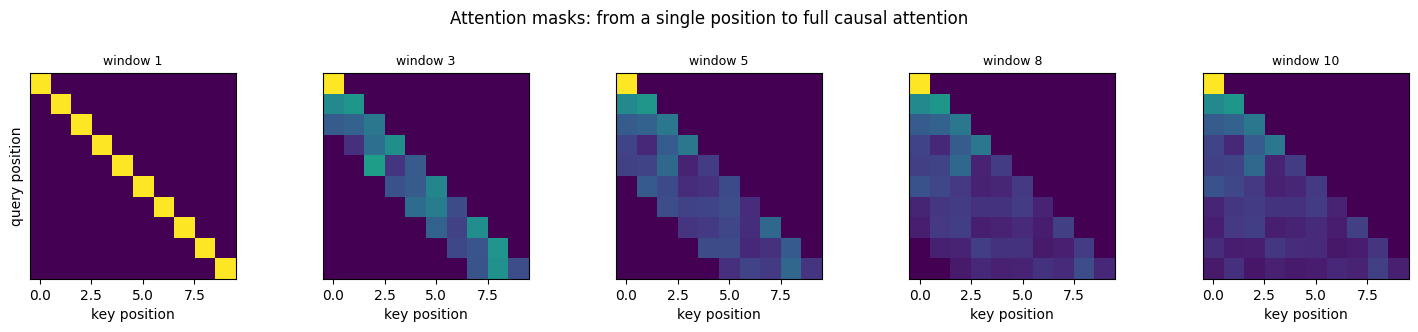

In [14]:
# Static sweep: what the causal mask does to the attention pattern.
fig, ax = plt.subplots(1, 5, figsize=(15, 3.0))
T_v = 10
X_v = torch.randn(T_v, d_model)
for a_, keep in zip(ax, [1, 3, 5, 8, T_v]):
    m = torch.zeros(T_v, T_v, dtype=torch.bool)
    for i in range(T_v):
        m[i, max(0, i - keep + 1):i + 1] = False
        m[i, :max(0, i - keep + 1)] = True
        m[i, i + 1:] = True
    _, A_v = mha(X_v, mask=m)
    a_.imshow(A_v[0].detach(), cmap='viridis'); a_.set_xlabel('key position')
    a_.set_title(f'window {keep}', fontsize=9)
    a_.set_yticks([])
ax[0].set_ylabel('query position')
fig.suptitle('Attention masks: from a single position to full causal attention', y=1.04)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [15]:
# Live: heads, sequence length, and the effect of masking.
from ipywidgets import interact, IntSlider, Checkbox

def show_attn(head=0, T_show=10, causal_mask=True):
    torch.manual_seed(0)
    Xs = torch.randn(T_show, d_model)
    m = torch.triu(torch.ones(T_show, T_show, dtype=torch.bool), diagonal=1) if causal_mask else None
    _, A_s = mha(Xs, mask=m)
    fig, a_ = plt.subplots(figsize=(4.6, 4.2))
    im = a_.imshow(A_s[head].detach(), cmap='viridis')
    a_.set_xlabel('key position'); a_.set_ylabel('query position')
    a_.set_title(f'head {head}, T={T_show}, causal={causal_mask}\nrow sums {A_s[head].sum(-1).mean():.3f}')
    plt.colorbar(im, ax=a_, fraction=0.046)
    plt.tight_layout(); plt.show()

interact(show_attn, head=IntSlider(min=0, max=7, step=1, value=0),
                    T_show=IntSlider(min=4, max=20, step=2, value=10),
                    causal_mask=Checkbox(value=True));

interactive(children=(IntSlider(value=0, description='head', max=7), IntSlider(value=10, description='T_show',…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Motivation** | Sequential computation blocks parallelism, and RNN path length grows with sequence length; attention makes it constant |
| **Q, K, V** | $Q = XW^Q$, $K = XW^K$, $V = XW^V$; with $x \in \mathbb{R}^{512}$ and $q,k,v \in \mathbb{R}^{64}$ the projections are $512 \times 64$ |
| **Scaled dot-product** | $Z = \mathrm{softmax}(QK^\top/\sqrt{d_k})V$; with $d_k = 64$ the divisor is 8 |
| **Why scale** | Dot-product variance grows with $d_k$, saturating the softmax and collapsing its gradient |
| **Multi-head** | $h = 8$ heads at $d_k = d_{model}/h = 64$, concatenated and projected by $W^O$; shape-preserving; $4d_{model}^2 = 2^{20}$ parameters |
| **Positional encoding** | Self-attention is permutation-equivariant, so position must be injected — **added**, not concatenated |
| **Encoder** | $N=6$ layers, each self-attention + feedforward, both wrapped in $\mathrm{LayerNorm}(x + \mathrm{SubLayer}(x))$ |
| **Decoder** | $N=6$ layers with a **masked** self-attention sublayer, so no position attends to the future |

## Exercises

1. **The homework from the slides.** Are transformers faster or slower than LSTMs? Answer separately for *training* and for *autoregressive inference*, and justify each with the path-length and parallelism arguments from section 1.
2. **The unanswered question.** The slides ask why attention encoder outputs do not depend on input order, and never answer. Prove permutation equivariance, then say precisely what positional encoding changes.
3. **Head specialisation.** Plot the attention matrix for all 8 heads on the same input. Do any two heads look alike? What would it mean if they all did?
4. **Cost of attention.** Work out how compute and memory scale with sequence length $T$ for self-attention versus an RNN. At what $T$ does attention become the more expensive of the two?
5. **Break the mask.** Remove the causal mask from the decoder's first sublayer and show, numerically, that a prediction at position $t$ then depends on token $t+1$ — the leakage the mask exists to prevent.
